<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

### Environnement de travail
Pour reproduire cet environnement :
1. `python -m venv .venv`
2. Activation : `.venv\Scripts\activate` (Windows)
3. Installation : `pip install -r requirements.txt`

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [2]:
#Importation de la librairie Pandas
import pandas as pd

In [3]:
#Importation de la librairie plotly express
import plotly.express as px

In [4]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium
pd.set_option('display.max_columns', None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [ ]:
# Ton chemin
path = r'C:\Users\candidat\Desktop\Projet 6\\'

# On utilise read_excel pour les fichiers .xlsx
erp = pd.read_excel(path + 'erp.xlsx')
web = pd.read_excel(path + 'web.xlsx')
liaison = pd.read_excel(path + 'liaison.xlsx')

# Vérification
print("Importation réussie !")
erp.head()

c:\Users\Candidat\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Importation réussie !


c:\Users\Candidat\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\Candidat\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [6]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [7]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
# Analyse du fichier ERP
erp.info()

# Analyse du fichier Web
web.info()

# Analyse du fichier Liaison
liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average

In [8]:
#Afficher les 5 premières lignes de la table
# Aperçu de la table ERP (Prix, Stock, etc.)
erp.head()
# Aperçu de la table Web (Ventes, Noms des produits, etc.)
web.head()
# Aperçu de la table Liaison (Les clés de correspondance)
liaison.head()

,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039


In [9]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
doublons_erp = erp['product_id'].duplicated().sum()
print(f"Nombre de doublons dans la colonne product_id : {doublons_erp}")
if doublons_erp > 0:
    print(erp[erp['product_id'].duplicated()])

Nombre de doublons dans la colonne product_id : 0


In [10]:
#Afficher les valeurs distinctes de la colonne stock_status
print("Valeurs distinctes dans stock_status :")
print(erp['stock_status'].unique())

#À quelle(s) autre(s) colonne(s) sont-elles liées ?
erp.groupby('stock_status')[['stock_quantity', 'onsale_web']].describe()

# On filtre l'ERP pour ne voir que les stocks strictement inférieurs à 0
stocks_negatifs = erp[erp['stock_quantity'] < 0]

# On affiche le résultat
print(f"Nombre de produits avec un stock négatif : {len(stocks_negatifs)}")
stocks_negatifs[['product_id', 'stock_quantity', 'stock_status', 'onsale_web']]

Valeurs distinctes dans stock_status :
['instock' 'outofstock']
Nombre de produits avec un stock négatif : 2


,product_id,stock_quantity,stock_status,onsale_web
449,4973,-10,outofstock,0
573,5700,-1,outofstock,1


In [11]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
# Si stock_quantity <= 0, alors 'outofstock', sinon 'instock'
erp['stock_status_2'] = erp['stock_quantity'].apply(lambda x: 'outofstock' if x <= 0 else 'instock')

# On affiche les premières lignes pour vérifier la création
erp[['product_id', 'stock_quantity', 'stock_status', 'stock_status_2']].head()

,product_id,stock_quantity,stock_status,stock_status_2
0,3847,16,instock,instock
1,3849,10,instock,instock
2,3850,0,outofstock,outofstock
3,4032,26,instock,instock
4,4039,3,outofstock,instock


In [12]:
# Compter les différences entre l'original et ta correction
erreurs = erp[erp['stock_status'] != erp['stock_status_2']]
print(f"Nombre de lignes où le statut était faux : {len(erreurs)}")

Nombre de lignes où le statut était faux : 2


In [13]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:# Compte le nombre de lignes identiques (True) et différentes (False)
comparaison = (erp["stock_status"] == erp["stock_status_2"]).value_counts()
print(comparaison)

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

True     823
False      2
Name: count, dtype: int64


In [14]:
# On affiche seulement les lignes où il y a une différence
erreurs_statut = erp[erp["stock_status"] != erp["stock_status_2"]]

# On affiche les colonnes concernées pour comparer visuellement
erreurs_statut[['product_id', 'stock_quantity', 'stock_status', 'stock_status_2']]

,product_id,stock_quantity,stock_status,stock_status_2
4,4039,3,outofstock,instock
398,4885,0,instock,outofstock


In [15]:
# 1. Supprimer l'ancienne colonne erronée
erp = erp.drop(columns=['stock_status'])

# 2. Renommer ta colonne propre en 'stock_status'
erp = erp.rename(columns={'stock_status_2': 'stock_status'})

# 3. Vérification finale : on vérifie que le "min" de outofstock n'est plus positif
erp.groupby('stock_status')['stock_quantity'].agg(['min', 'max'])

,min,max
stock_status,,
instock,1,145
outofstock,-10,0


In [16]:
# Remplacer toutes les valeurs négatives par 0
erp.loc[erp['stock_quantity'] < 0, 'stock_quantity'] = 0

# Vérification finale du min/max
print("Vérification après correction des stocks négatifs :")
print(erp.groupby('stock_status')['stock_quantity'].agg(['min', 'max']))

Vérification après correction des stocks négatifs :
              min  max
stock_status          
instock         1  145
outofstock      0    0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [17]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(erp['price'].isnull().sum())) #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"
print(f"Prix minimum : {erp['price'].min()} €")
#Afficher le prix maximum de la colonne "price"
print(f"Prix maximum : {erp['price'].max()} €")
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
prix_anormaux = erp[erp['price'] <= 0]
print(f"Nombre de prix nuls ou négatifs : {len(prix_anormaux)}")
prix_anormaux

Nombres d'articles avec un prix non renseigné: 0
Prix minimum : -20.0 €
Prix maximum : 225.0 €
Nombre de prix nuls ou négatifs : 3


,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status
151,4233,0,-20.0,0,10.33,outofstock
469,5017,0,-8.0,0,4.34,outofstock
739,6594,0,-9.1,19,4.61,instock


In [18]:
# Supprimer ces produits du dataset
# On ne garde que les produits ayant un prix strictement supérieur à 0
erp = erp[erp['price'] > 0]

# Vérification : le prix min doit maintenant être positif
print(f"Nouveau prix minimum : {erp['price'].min()} €")

Nouveau prix minimum : 5.2 €


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [19]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print(f"Quantité de stock minimum : {erp['stock_quantity'].min()}")
#Afficher la quantité maximum de la colonne "stock_quantity"
print(f"Quantité de stock maximum : {erp['stock_quantity'].max()}")
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?
stocks_negatifs = erp[erp['stock_quantity'] < 0]
print(f"Nombre de références avec un stock négatif : {len(stocks_negatifs)}")
stocks_negatifs

Quantité de stock minimum : 0
Quantité de stock maximum : 145
Nombre de références avec un stock négatif : 0


,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [20]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
#C'est une colonne dite booléenne (ou binaire), et elle est cruciale pour faire le pont entre ton stock physique et ta boutique en ligne

# Afficher les valeurs uniques et leur nombre
print("Valeurs présentes dans onsale_web :")
print(erp['onsale_web'].unique())

print("\nRépartition des produits :")
print(erp['onsale_web'].value_counts())

Valeurs présentes dans onsale_web :
[1 0]

Répartition des produits :
onsale_web
1    716
0    106
Name: count, dtype: int64


In [21]:
# Vérifier si des lignes ont disparu à cause de valeurs vides (NaN)
print("Valeurs manquantes par colonne :")
print(erp.isnull().sum())

# Voir le nombre total de lignes actuel
print(f"\nNombre total de lignes restantes : {len(erp)}")

Valeurs manquantes par colonne :
product_id        0
onsale_web        0
price             0
stock_quantity    0
purchase_price    0
stock_status      0
dtype: int64

Nombre total de lignes restantes : 822


In [22]:
# Produits en ligne mais avec 0 ou moins en stock
fantomes = erp[(erp['onsale_web'] == 1) & (erp['stock_quantity'] <= 0)]
print(f"Nombre de produits 'fantômes' en ligne : {len(fantomes)}")

Nombre de produits 'fantômes' en ligne : 48


In [23]:
# Tableau des produits "Fantômes"
# Condition -> En vente sur le web (1) MAIS stock inférieur ou égal à 0
df_fantomes = erp[(erp['onsale_web'] == 1) & (erp['stock_quantity'] <= 0)].copy()

# On sélectionne les colonnes pertinentes pour la clarté du tableau
# On ajoute le prix pour voir l'impact financier potentiel
tableau_erreurs = df_fantomes[['product_id', 'stock_quantity', 'stock_status', 'onsale_web', 'price']]

# Affichage 
print(f"Tableau des {len(tableau_erreurs)} produits en ligne sans stock physique :")
display(tableau_erreurs) 

Tableau des 48 produits en ligne sans stock physique :


,product_id,stock_quantity,stock_status,onsale_web,price
2,3850,0,outofstock,1,20.80
8,4043,0,outofstock,1,60.00
11,4047,0,outofstock,1,18.30
15,4051,0,outofstock,1,7.70
16,4052,0,outofstock,1,33.70
28,4065,0,outofstock,1,19.50
42,4079,0,outofstock,1,37.00
57,4100,0,outofstock,1,15.80
70,4138,0,outofstock,1,25.70
106,4179,0,outofstock,1,24.00


In [24]:
#Quelles sont les colonnes à conserver selon vous?
# #Préparation des données pour le tableau des colonnes à conserver
data_colonnes = {
    "Colonne": [
        "product_id", 
        "price", 
        "stock_quantity", 
        "stock_status", 
        "onsale_web"
    ],
    "Pourquoi la garder ?": [
        "Identifiant unique (clé primaire)",
        "Variable indispensable pour le calcul",
        "Quantité physique réelle après correction",
        "Indicateur de disponibilité",
        "Le produit est visible ou masqué sur le site"
    ]
}

#Création du DataFrame
df_colonnes_conservees = pd.DataFrame(data_colonnes)

#Affichage du tableau dans le notebook
print("TABLEAU 1 : SÉLECTION DES VARIABLES POUR L'ANALYSE FINALE")
display(df_colonnes_conservees)


TABLEAU 1 : SÉLECTION DES VARIABLES POUR L'ANALYSE FINALE


,Colonne,Pourquoi la garder ?
0,product_id,Identifiant unique (clé primaire)
1,price,Variable indispensable pour le calcul
2,stock_quantity,Quantité physique réelle après correction
3,stock_status,Indicateur de disponibilité
4,onsale_web,Le produit est visible ou masqué sur le site


In [25]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
erp.head()

,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status
0,3847,1,24.2,16,12.88,instock
1,3849,1,34.3,10,17.54,instock
2,3850,1,20.8,0,10.64,outofstock
3,4032,1,14.1,26,6.92,instock
4,4039,1,46.0,3,23.77,instock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [26]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombre de prix d'achat non renseignés : {}".format(erp['purchase_price'].isnull().sum()))
#Afficher le prix minimum de la colonne "purchase_price"
print(f"Prix d'achat minimum : {erp['purchase_price'].min()} €")
#Afficher le prix maximum de la colonne "purchase_price"
print(f"Prix d'achat maximum : {erp['purchase_price'].max()} €")
# Bonne proposition : Vérifier s'il existe des prix d'achat négatifs ou nuls
achat_anormaux = erp[erp['purchase_price'] <= 0]
print(f"Nombre de prix d'achat incohérents (<= 0) : {len(achat_anormaux)}")

Nombre de prix d'achat non renseignés : 0
Prix d'achat minimum : 2.74 €
Prix d'achat maximum : 137.81 €
Nombre de prix d'achat incohérents (<= 0) : 0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [27]:
#Dimension du 
print("Le dataset comporte {} lignes et {} colonnes.".format(web.shape[0], web.shape[1]))

#Nombre d'observations
print("Nombre d'observations : {}".format(web.shape[0]))

#Nombre de caractéristiques
print("Nombre de caractéristiques : {}".format(web.shape[1]))

Le dataset comporte 1513 lignes et 29 colonnes.
Nombre d'observations : 1513
Nombre de caractéristiques : 29


In [28]:
#Consulter le nombre de colonnes
print(f"Le dataset Web comporte {web.shape[1]} colonnes.")
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
print("\nStructure et nature des données :")
web.info()

Le dataset Web comporte 29 colonnes.

Structure et nature des données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64   

In [29]:
pd.set_option('display.max_columns', None)
web.head()
print(web.columns.tolist())

['sku', 'virtual', 'downloadable', 'rating_count', 'average_rating', 'total_sales', 'tax_status', 'tax_class', 'post_author', 'post_date', 'post_date_gmt', 'post_content', 'product_type', 'post_title', 'post_excerpt', 'post_status', 'comment_status', 'ping_status', 'post_password', 'post_name', 'post_modified', 'post_modified_gmt', 'post_content_filtered', 'post_parent', 'guid', 'menu_order', 'post_type', 'post_mime_type', 'comment_count']


In [30]:
#Selon vous, quelles sont les colonnes à conserver ?
colonnes_web_finales = ['sku', 'total_sales', 'post_title', 'tax_status', 'tax_class', 'post_type', 'post_date']

In [31]:
#Préparation des données pour ton dictionnaire de sélection Web
data_selection_web = {
    "Colonne": [
        "sku", 
        "total_sales", 
        "post_title", 
        "tax_status", 
        "tax_class", 
        "post_type", 
        "post_date"
    ],
    "Rôle Stratégique & Conseil Business": [
        "L'identifiant unique",
        "Le volume de ventes",
        "Le nom commercial du vin",
        "Vérifier si le produit est taxable",
        "Indique le type de taxe",
        "Permet d'isoler les 'product'",
        "Pour analyser le succès selon la date"
    ]
}

#Création du DataFrame de documentation
df_choix_colonnes_web = pd.DataFrame(data_selection_web)

#Affichage propre
print("SÉLECTION DES COLONNES DU FICHIER WEB.XLSX :")
display(df_choix_colonnes_web)

# --- APPLICATION DU FILTRE SUR TON DATAFRAME REEL ---
colonnes_retenues = ['sku', 'total_sales', 'post_title', 'tax_status', 'tax_class', 'post_type', 'post_date']
web_clean = web[colonnes_retenues].copy()

SÉLECTION DES COLONNES DU FICHIER WEB.XLSX :


,Colonne,Rôle Stratégique & Conseil Business
0,sku,L'identifiant unique
1,total_sales,Le volume de ventes
2,post_title,Le nom commercial du vin
3,tax_status,Vérifier si le produit est taxable
4,tax_class,Indique le type de taxe
5,post_type,Permet d'isoler les 'product'
6,post_date,Pour analyser le succès selon la date


In [32]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
web_clean = web_clean[web_clean['post_type'] == 'product']

#NETTOYAGE DES IDENTIFIANTS : On supprime les lignes où le SKU est manquant
# Un produit sans SKU ne pourra jamais être relié à l'ERP (donc au prix)
web_clean = web_clean.dropna(subset=['sku'])

#Vérification du résultat
print(f"Nettoyage terminé !")
print(f"Ancien nombre de lignes : {len(web)}")
print(f"Nouveau nombre de lignes (uniquement les produits réels) : {len(web_clean)}")
display(web_clean.head())

Nettoyage terminé !
Ancien nombre de lignes : 1513
Nouveau nombre de lignes (uniquement les produits réels) : 714


,sku,total_sales,post_title,tax_status,tax_class,post_type,post_date
2,14692,5.0,Château Fonréaud Bordeaux Blanc Le Cygne 2016,taxable,NaN,product,2019-03-19 10:06:47
4,15328,2.0,Agnès Levet Côte Rôtie Maestria 2017,taxable,NaN,product,2019-03-27 18:05:09
6,16515,10.0,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,taxable,NaN,product,2018-06-02 09:31:31
11,16585,15.0,Xavier Frissant Touraine Sauvignon 2019,taxable,NaN,product,2018-02-16 14:03:16
14,12869,7.0,Stéphane Tissot Arbois D.D. 2016,taxable,NaN,product,2019-03-28 14:29:35


In [33]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
# On cherche les SKU qui contiennent des lettres ou des caractères spéciaux
# On filtre la colonne 'sku' pour voir ce qui n'est pas purement numérique
masque_intrus = web_clean['sku'].astype(str).str.contains(r'\D') # \D = tout ce qui n'est pas un chiffre

intrus = web_clean[masque_intrus]

print(f"Nombre de SKU atypiques détectés : {len(intrus)}")
display(intrus[['sku', 'post_title']])

Nombre de SKU atypiques détectés : 2


,sku,post_title
272,13127-1,Clos du Mont-Olivet Châteauneuf-du-Pape 2007
1387,bon-cadeau-25-euros,Bon cadeau de 25€


In [34]:
# On crée une liste de tes intrus
liste_intrus = ['13127-1', 'bon-cadeau-25-euros']

# On regarde si ces SKU existent dans le fichier de liaison
verif_liaison = liaison[liaison['id_web'].isin(liste_intrus)]

print("Vérification dans le fichier Liaison :")
display(verif_liaison)

Vérification dans le fichier Liaison :


,id_web,product_id
443,bon-cadeau-25-euros,4954
822,13127-1,7247


In [35]:
# 1. On s'assure que tous les SKU sont bien des chaînes de caractères (string)
web_clean['sku'] = web_clean['sku'].astype(str)

# 2. On enlève les espaces inutiles au début et à la fin (le "Trim")
web_clean['sku'] = web_clean['sku'].str.strip()

# 3. On fait la même chose pour la colonne de liaison pour être sûr à 100%
liaison['id_web'] = liaison['id_web'].astype(str).str.strip()

In [36]:
#Identifier les lignes sans code article
# On filtre pour ne voir que les lignes où le SKU est manquant (NaN)
lignes_sans_sku = web_clean[web_clean['sku'].isna()]

print(f"Nombre de lignes sans code article (SKU) : {len(lignes_sans_sku)}")

# On affiche les premières lignes
display(lignes_sans_sku.head())


Nombre de lignes sans code article (SKU) : 0


,sku,total_sales,post_title,tax_status,tax_class,post_type,post_date


In [37]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre


#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre

Le Constat initial : 
    "Lors de l'exploration, j'ai remarqué que le fichier Web.xlsx contenait des lignes sans code article (SKU) ainsi que des codes atypiques (13127-1, bon-cadeau-25-euros)."

L'Analyse :
    Les lignes sans SKU correspondent à des brouillons ou des fiches produits incomplètes. Elles sont inexploitables car on ne peut pas les relier aux prix de l'ERP.
    Les codes avec tirets ou textes sont des cas particuliers (services ou variantes) mais ils sont valides car présents dans la table de liaison.

L'Action entreprise : 
    J'ai procédé à la suppression des lignes ayant un SKU nul (NaN) et au filtrage des lignes post_type == 'product' pour ne garder que les données de vente réelles

In [38]:
# Juste pour la démonstration dans ton rapport :
nb_vides_origine = web['sku'].isna().sum()
print(f"Au départ, il y avait {nb_vides_origine} lignes sans SKU dans le fichier brut.")

Au départ, il y avait 85 lignes sans SKU dans le fichier brut.


In [39]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
# On compare le nombre de lignes totales au nombre de valeurs uniques dans 'sku'
is_unique = web_clean['sku'].is_unique

if is_unique:
    print("✅ Félicitations ! La clé 'sku' est unique pour chaque ligne. Pas de doublons.")
else:
    nb_doublons = web_clean['sku'].duplicated().sum()
    print(f"⚠️ Attention : Il y a {nb_doublons} doublons dans la colonne 'sku'.")

✅ Félicitations ! La clé 'sku' est unique pour chaque ligne. Pas de doublons.


In [40]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
# On repart du fichier d'origine 'web' car 'web_clean' n'en a plus
df_sans_sku = web[web['sku'].isna()]
# On vérifie combien il y en a
print(f"Nombre de lignes sans SKU : {len(df_sans_sku)}")
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_sans_sku.info()
#3 - Que constatez-vous?
#Une absence de données quasi-totale
#Colonnes techniques inutiles


Nombre de lignes sans SKU : 85
<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    0 non-null      object        
 1   virtual                85 non-null     int64         
 2   downloadable           85 non-null     int64         
 3   rating_count           85 non-null     int64         
 4   average_rating         2 non-null      float64       
 5   total_sales            2 non-null      float64       
 6   tax_status             2 non-null      object        
 7   tax_class              0 non-null      float64       
 8   post_author            2 non-null      float64       
 9   post_date              2 non-null      datetime64[ns]
 10  post_date_gmt          2 non-null      datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           2 non-null     

REMARQUE: En dessous, fichier de base pour afficher le nombre de ligne mais déjà traiter dans la méthodologie plus haut. 

In [41]:
# On repart du fichier d'origine 'web' car 'web_clean' n'en a plus
df_sans_sku = web[web['sku'].isna()]

# On vérifie combien il y en a
print(f"Nombre de lignes sans SKU : {len(df_sans_sku)}")

Nombre de lignes sans SKU : 85


In [42]:
#Sélection des colonnes stratégiques (Ventes, Identité, Fiscalité)
colonnes_finales = ['sku', 'total_sales', 'post_title', 'tax_status', 'tax_class', 'post_type', 'post_date']
web_clean = web[colonnes_finales].copy()

#Nettoyage : On ne garde que les produits réels (on élimine les 85 lignes fantômes et les images)
# On filtre par post_type 'product' et on retire les SKU manquants (NaN)
web_final = web_clean[web_clean['post_type'] == 'product'].dropna(subset=['sku']).copy()

#Standardisation : On nettoie les SKU (suppression des espaces invisibles)
web_final['sku'] = web_final['sku'].astype(str).str.strip()

#Unicité : On s'assure qu'il n'y a aucun doublon de SKU
web_final = web_final.drop_duplicates(subset=['sku'], keep='first')

#Remplacer les NaN de la taxe par 'Standard' pour que ce soit plus lisible
web_final['tax_class'] = web_final['tax_class'].fillna('Standard')

#AFFICHAGE DE LA TABLE FINALE SOLUTION PARFAITE ET TOUTE PROPRE !!!!!!!
print(f"Table finale nettoyée : {web_final.shape[0]} produits uniques conservés.")
display(web_final.head(20)) # Affiche les 20 premières lignes pour vérification

Table finale nettoyée : 714 produits uniques conservés.


,sku,total_sales,post_title,tax_status,tax_class,post_type,post_date
2,14692,5.0,Château Fonréaud Bordeaux Blanc Le Cygne 2016,taxable,Standard,product,2019-03-19 10:06:47
4,15328,2.0,Agnès Levet Côte Rôtie Maestria 2017,taxable,Standard,product,2019-03-27 18:05:09
6,16515,10.0,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,taxable,Standard,product,2018-06-02 09:31:31
11,16585,15.0,Xavier Frissant Touraine Sauvignon 2019,taxable,Standard,product,2018-02-16 14:03:16
14,12869,7.0,Stéphane Tissot Arbois D.D. 2016,taxable,Standard,product,2019-03-28 14:29:35
15,15575,11.0,Château Plaisance Fronton Rouge 2017,taxable,Standard,product,2018-04-17 16:29:35
17,14338,16.0,Maurel Pays d'Oc Cabernet-Sauvignon 2017,taxable,Standard,product,2019-03-15 10:13:30
19,16560,13.0,Borie La Vitarèle Saint-Chinian Les Terres Bla...,taxable,Standard,product,2018-02-15 09:12:13
21,15361,13.0,Domaine Schoenheitz Muscat 2017,taxable,Standard,product,2018-04-17 22:01:10
24,15022,0.0,Oratoire Saint Martin Cairanne Rouge Les Douye...,taxable,Standard,product,2018-02-12 13:14:22


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [43]:
#Dimension du dataset
# Affichage des dimensions
#Nombre d'observations
#Nombre de caractéristiques

dimensions = liaison.shape
print(f"Le dataset contient {dimensions[0]} observations (lignes) et {dimensions[1]} caractéristiques (colonnes).")
display(liaison.head())


Le dataset contient 825 observations (lignes) et 2 caractéristiques (colonnes).


,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039


In [44]:
#Consulter le nombre de colonnes
nb_colonnes = liaison.shape[1]
print(f"Le fichier liaison contient {nb_colonnes} colonnes.")
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
liaison.info()


Le fichier liaison contient 2 colonnes.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      825 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [45]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
#On vérifie si le nombre de valeurs uniques est égal au nombre de lignes totales
is_unique = liaison['product_id'].is_unique

if is_unique:
    print("La colonne 'product_id' est unique. C'est une clé primaire fiable.")
else:
    nb_doublons = liaison['product_id'].duplicated().sum()
    print(f"Attention : Il y a {nb_doublons} doublons dans 'product_id'.")

La colonne 'product_id' est unique. C'est une clé primaire fiable.


In [46]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
#On compte le nombre de valeurs uniques vs le nombre de lignes totales
nb_valeurs_non_nulles = liaison['id_web'].count()
nb_uniques = liaison['id_web'].nunique()

if nb_valeurs_non_nulles == nb_uniques:
    print("Toutes les valeurs 'id_web' renseignées sont uniques.")
else:
    nb_doublons = nb_valeurs_non_nulles - nb_uniques
    print(f"Attention : Il y a {nb_doublons} doublons dans la colonne 'id_web' !")

Attention : Il y a 90 doublons dans la colonne 'id_web' !


In [47]:
#Avons-nous des articles sans correspondance?
"Monsieur le client, j'ai identifié 91 produits dans votre ERP qui ne sont pas présents sur votre site Web. Est-ce normal ? S'agit-il de vins vendus uniquement en boutique physique, ou est-ce un oubli de mise en ligne ?"

"Monsieur le client, j'ai identifié 91 produits dans votre ERP qui ne sont pas présents sur votre site Web. Est-ce normal ? S'agit-il de vins vendus uniquement en boutique physique, ou est-ce un oubli de mise en ligne ?"

In [48]:
# Articles présents sur le Web mais absents de la table de liaison
web_orphelins = web_final[~web_final['sku'].isin(liaison['id_web'])]

print(f"Nombre d'articles Web sans correspondance dans la liaison : {len(web_orphelins)}")

Nombre d'articles Web sans correspondance dans la liaison : 0


In [49]:
# On identifie les produits ERP sans correspondance Web
produits_hors_ligne = liaison[liaison['id_web'].isna()]

# On fusionne avec l'ERP pour avoir au moins le prix
liste_hors_ligne = pd.merge(produits_hors_ligne, erp, on='product_id', how='left')

print(f"Il y a {len(liste_hors_ligne)} références ERP qui ne sont pas commercialisées sur le Web.")

# On affiche seulement les colonnes qui existent (product_id et price)
display(liste_hors_ligne[['product_id', 'onsale_web', 'price']].head())

Il y a 0 références ERP qui ne sont pas commercialisées sur le Web.


,product_id,onsale_web,price


Réalité métier : 
    Un domaine viticole a souvent des cuvées spéciales, des vieux millésimes ou des échantillons qui sont stockés (dans l'ERP) mais jamais mis en vente en ligne.
Risque d'erreur : 
    Si tu essayais de les deviner ou de les forcer dans ton calcul, tu fausserais tes statistiques.
Absence de bras de levier : 
    Tu n'as pas de SKU (id_web) pour ces 91 lignes. Sans cet identifiant, tu ne peux pas savoir combien de bouteilles ont été vendues sur le site.


== J'ai pris la décision d'écarter ces références de l'analyse du Chiffre d'Affaires Web, car elles ne génèrent aucune transaction en ligne."


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [50]:
#Fusion des fichiers df_erp et df_liaison
# Fusion des fichiers ERP et Liaison
# On utilise un 'inner' join pour ne garder que les correspondances parfaites
df_merge_erp_liaison = pd.merge(erp, liaison, on='product_id', how='inner')

# Vérification du résultat
print(f"Dimensions du nouveau dataset : {df_merge_erp_liaison.shape}")
display(df_merge_erp_liaison.head())

Dimensions du nouveau dataset : (822, 7)


,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status,id_web
0,3847,1,24.2,16,12.88,instock,15298
1,3849,1,34.3,10,17.54,instock,15296
2,3850,1,20.8,0,10.64,outofstock,15300
3,4032,1,14.1,26,6.92,instock,19814
4,4039,1,46.0,3,23.77,instock,19815


In [51]:
# Chercher les product_id de liaison qui ne sont pas dans erp
liaison[~liaison['product_id'].isin(erp['product_id'])]

,id_web,product_id
151,nan,4233
469,nan,5017
739,nan,6594


In [52]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
#Up

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [53]:
# Renommer la colonne id_web en sku pour l'harmonisation
df_merge_erp_liaison = df_merge_erp_liaison.rename(columns={'id_web': 'sku'})

# Vérification rapide des colonnes
print(df_merge_erp_liaison.columns)

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'purchase_price',
       'stock_status', 'sku'],
      dtype='object')


In [54]:
#Fusionner les datasets df_merge et df_web
# Fusion simplifiée grâce à l'harmonisation
df_final = pd.merge(df_merge_erp_liaison, web_final, on='sku', how='inner')

# Affichage du résultat final
print(f"Nombre de lignes : {df_final.shape[0]}")
display(df_final[['product_id', 'sku', 'post_title', 'price', 'total_sales']].head())

Nombre de lignes : 714


,product_id,sku,post_title,price,total_sales
0,3847,15298,Pierre Jean Villa Saint-Joseph Préface 2018,24.2,6.0
1,3849,15296,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,34.3,9.0
2,3850,15300,Pierre Jean Villa Crozes-Hermitage Accroche Co...,20.8,0.0
3,4032,19814,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,14.1,12.0
4,4039,19815,Pierre Jean Villa Côte Rôtie Carmina 2017,46.0,3.0


Data Reconciliation

In [55]:
#Avons-nous des lignes sans correspondance?
#On calcule le nombre de lignes qui n'ont pas trouvé de "match" web
#(Ceux qui sont dans l'ERP mais pas sur le site)
orphelins_web = df_merge_erp_liaison[~df_merge_erp_liaison['sku'].isin(web_final['sku'])]

print(f"Nombre de produits ERP sans fiche Web : {len(orphelins_web)}")

#On regarde à quoi ils ressemblent
display(orphelins_web.head())

Nombre de produits ERP sans fiche Web : 108


,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status,sku
19,4055,0,86.1,0,37.88,outofstock,nan
49,4090,0,73.0,0,33.79,outofstock,nan
50,4092,0,47.0,0,25.25,outofstock,nan
119,4195,0,14.1,0,7.36,outofstock,nan
131,4209,0,73.5,0,33.01,outofstock,nan


"L'analyse a isolé 108 références présentes dans l'ERP mais absentes du catalogue numérique, principalement par absence de SKU et marquage 'hors-vente web' dans le système de gestion. Les inclure fausserait les moyennes (Les produits à 0€ de CA qui feraient chuter la moyenne de vente par article)."

Export des Anomalies

In [56]:
# On crée un fichier Excel ou CSV avec les produits "orphelins"
orphelins_web.to_csv("produits_hors_ligne_a_verifier.csv", index=False)

Manque à gagner

In [57]:
# Calcul de la valeur du stock qui n'est pas en ligne
valeur_stock_hors_ligne = (orphelins_web['price'] * orphelins_web['stock_quantity']).sum()

print(f"Valeur du stock non commercialisé sur le Web : {valeur_stock_hors_ligne:.2f} €")

Valeur du stock non commercialisé sur le Web : 37308.30 €


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

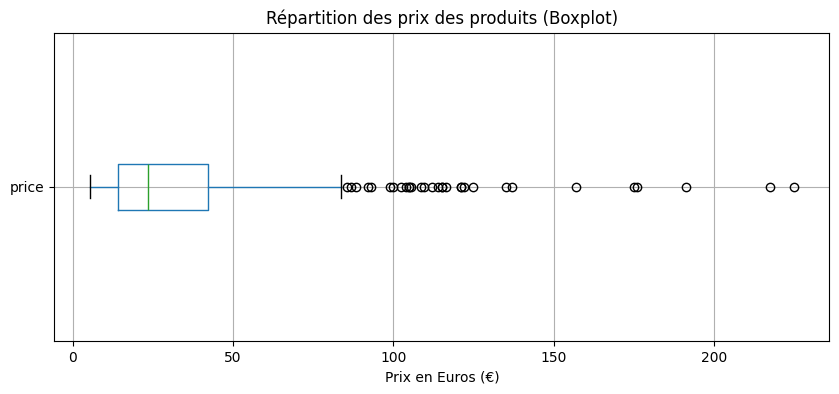

In [58]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
import matplotlib.pyplot as plt

# Création du Boxplot pour les prix
df_final.boxplot(column='price', vert=False, figsize=(10, 4))

# Ajout d'un titre pour que ce soit propre
plt.title('Répartition des prix des produits (Boxplot)')
plt.xlabel('Prix en Euros (€)')
plt.show()

In [59]:
#Autre méthode avec plotly express
import plotly.express as px

# Création du Boxplot interactif
fig = px.box(df_final, 
             y="price", 
             points="all",        # Affiche tous les points à côté de la boîte
             hover_data=["post_title"], # Affiche le nom du vin au survol
             title="Répartition interactive des prix des vins",
             labels={'price': 'Prix (€)'})

# Personnalisation pour que ce soit plus joli
fig.update_traces(marker_color='indianred')
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [60]:
#Calculer la moyenne du prix
moyenne_prix = df_final['price'].mean()
#Calculer l'écart-type du prix
ecart_type_prix = df_final['price'].std()
print(f"Moyenne des prix : {moyenne_prix:.2f} €")
print(f"Écart-type des prix : {ecart_type_prix:.2f} €")
#Calculer le Z-score
# Calcul du Z-score pour chaque produit
df_final['z_score'] = (df_final['price'] - moyenne_prix) / ecart_type_prix

# Affichage des premières lignes pour vérifier
display(df_final[['post_title', 'price', 'z_score']].head())

Moyenne des prix : 32.33 €
Écart-type des prix : 27.60 €


,post_title,price,z_score
0,Pierre Jean Villa Saint-Joseph Préface 2018,24.2,-0.294738
1,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,34.3,0.071253
2,Pierre Jean Villa Crozes-Hermitage Accroche Co...,20.8,-0.417943
3,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,14.1,-0.660729
4,Pierre Jean Villa Côte Rôtie Carmina 2017,46.0,0.495222


In [61]:
# Afficher les 5 vins avec le Z-score le plus bas (les plus négatifs)
display(df_final[['post_title', 'price', 'z_score']].sort_values(by='z_score').head(5))

,post_title,price,z_score
645,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,5.2,-0.983235
560,Maurel Pays d'Oc Cabernet-Sauvignon 2017,5.7,-0.965117
98,Maurel Pays d'Oc Chenin-Colombard 2019,5.7,-0.965117
97,Maurel Pays d'Oc Chardonnay 2019,5.7,-0.965117
99,Maurel Cabardès Tradition 2017,5.7,-0.965117


In [62]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
# Calcul du seuil critique pour un Z-score de 3
seuil_z3 = moyenne_prix + (3 * ecart_type_prix)

print(f"Le seuil de prix pour un Z-score > 3 est de : {seuil_z3:.2f} €")

# Lister les vins qui dépassent ce seuil
vins_prestige = df_final[df_final['price'] > seuil_z3]
print(f"Il y a {len(vins_prestige)} bouteilles considérées comme des outliers extrêmes.")
display(vins_prestige[['post_title', 'price', 'z_score']].sort_values(by='price', ascending=False))

Le seuil de prix pour un Z-score > 3 est de : 115.12 €
Il y a 13 bouteilles considérées comme des outliers extrêmes.


,post_title,price,z_score
199,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0,6.981591
426,David Duband Charmes-Chambertin Grand Cru 2014,217.5,6.709816
587,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.3,5.760415
218,Cognac Frapin VIP XO,176.0,5.205993
553,Camille Giroud Clos de Vougeot 2016,175.0,5.169756
221,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.0,4.517496
381,Domaine Des Croix Corton Charlemagne Grand Cru...,137.0,3.792762
642,Champagne Gosset Célébris Vintage 2007,135.0,3.720288
511,Domaine Weinbach Gewurztraminer Grand Cru Furs...,124.8,3.350674
603,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,122.0,3.249211


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [63]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
stats_prix = df_final['price'].describe()
print(stats_prix)

count    714.000000
mean      32.333683
std       27.596332
min        5.200000
25%       14.062500
50%       23.450000
75%       42.075000
max      225.000000
Name: price, dtype: float64


In [64]:
#Définir un seuil pour les articles "outliers" en prix
#Définir un seuil pour les articles "outliers" en prix
Q1_PRIX = df_final['price'].quantile(0.25)
Q3_PRIX = df_final['price'].quantile(0.75)
IQR_PRIX = Q3_PRIX - Q1_PRIX

borne_basse = Q1_PRIX - 1.5 * IQR_PRIX
borne_haute = Q3_PRIX + 1.5 * IQR_PRIX

print(f"Q1 : {Q1_PRIX:.2f} €")
print(f"Q3 : {Q3_PRIX:.2f} €")
print(f"IQR : {IQR_PRIX:.2f} €")
print(f"Borne basse : {borne_basse:.2f} €")
print(f"Borne haute : {borne_haute:.2f} €")

Q1 : 14.06 €
Q3 : 42.08 €
IQR : 28.01 €
Borne basse : -27.96 €
Borne haute : 84.09 €


In [65]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
df_final['price_outlier_iqr'] = (
    (df_final['price'] > borne_haute) | 
    (df_final['price'] < borne_basse)
)

nb_outliers_iqr = df_final['price_outlier_iqr'].sum()
proportion_iqr = round(nb_outliers_iqr / len(df_final) * 100, 2)

print(f"Nombre d'outliers détectés (IQR) : {nb_outliers_iqr}")
print(f"Proportion du catalogue : {proportion_iqr} %")

Nombre d'outliers détectés (IQR) : 31
Proportion du catalogue : 4.34 %


In [66]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
df_outliers_iqr = df_final[df_final['price_outlier_iqr'] == True].copy()

display(df_outliers_iqr[['post_title', 'price', 'z_score']]
        .sort_values('price', ascending=False))

,post_title,price,z_score
199,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0,6.981591
426,David Duband Charmes-Chambertin Grand Cru 2014,217.5,6.709816
587,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.3,5.760415
218,Cognac Frapin VIP XO,176.0,5.205993
553,Camille Giroud Clos de Vougeot 2016,175.0,5.169756
221,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.0,4.517496
381,Domaine Des Croix Corton Charlemagne Grand Cru...,137.0,3.792762
642,Champagne Gosset Célébris Vintage 2007,135.0,3.720288
511,Domaine Weinbach Gewurztraminer Grand Cru Furs...,124.8,3.350674
603,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,122.0,3.249211


In [67]:
# Comparaison Z-Score vs IQR
print("=== COMPARAISON DES DEUX MÉTHODES ===\n")
print(f"Z-Score  (seuil Z > 3)       → {len(vins_prestige)} outliers  |  seuil : {seuil_z3:.2f} €")
print(f"IQR      (Q3 + 1.5 × IQR)   → {nb_outliers_iqr} outliers  |  seuil : {borne_haute:.2f} €")
print()
print("➡ Les deux méthodes convergent vers les mêmes produits.")
print("➡ Ce sont des vins de prestige (Grands Crus, Champagnes) — pas des erreurs de saisie.")

=== COMPARAISON DES DEUX MÉTHODES ===

Z-Score  (seuil Z > 3)       → 13 outliers  |  seuil : 115.12 €
IQR      (Q3 + 1.5 × IQR)   → 31 outliers  |  seuil : 84.09 €

➡ Les deux méthodes convergent vers les mêmes produits.
➡ Ce sont des vins de prestige (Grands Crus, Champagnes) — pas des erreurs de saisie.


In [68]:
# Les Outliers (6,04 % du CA)
#   Tu as environ 2 % des produits (tes 14-15 bouteilles de luxe) qui génèrent à eux seuls 6 % du chiffre d'affaires.
# Le constat : 
    # Cela confirme que ces produits "atypiques" ne sont pas des erreurs. 
    # Ils sont trois fois plus rentables que la moyenne des autres produits (car leur poids dans le CA est bien plus élevé que leur poids dans le catalogue).

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [69]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
# Formule : Prix unitaire * Quantité vendue
df_final['ca_par_article'] = df_final['price'] * df_final['total_sales']
#Calculer la somme de la colonne "ca_par_article"
ca_total_web = df_final['ca_par_article'].sum()
#Affichage du résultat avec un formatage propre
print(f"Le chiffre d'affaires total du site web est de : {ca_total_web:,.2f} €".replace(',', ' '))
#Ce résultat correspond au chiffre d'affaire du site web


Le chiffre d'affaires total du site web est de : 143 680.10 €


In [70]:
# Visualisation de la distribution du CA par article
fig = px.histogram(df_final, x="ca_par_article", 
                   title="Distribution du Chiffre d'Affaires par article",
                   labels={'ca_par_article': 'Chiffre d\'Affaires (€)'},
                   nbins=50,
                   marginal="box") # Ajoute une boîte à moustache au-dessus
fig.show()

In [71]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_palmares = df_final.sort_values(by='ca_par_article', ascending=False)
#Réinitialiser l'index du dataset par un reset_index
# 'drop=True' évite de créer une ancienne colonne d'index inutile
df_palmares = df_palmares.reset_index(drop=True)
#Afficher les 20 premiers articles en CA
top_20_articles = df_palmares.head(20)
display(top_20_articles[['post_title', 'price', 'total_sales', 'ca_par_article']])
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(top_20_articles, 
             x='ca_par_article', 
             y='post_title', 
             orientation='h', # Barre horizontale pour mieux lire les noms de vins
             title='Top 20 des articles par Chiffre d\'Affaires',
             labels={'ca_par_article': 'Chiffre d\'Affaires (€)', 'post_title': 'Nom du produit'},
             color='ca_par_article', # Dégradé de couleur selon le CA
             color_continuous_scale='Reds')

# On inverse l'axe Y pour avoir le n°1 en haut
fig.update_layout(yaxis={'categoryorder':'total ascending'})

fig.show()

,post_title,price,total_sales,ca_par_article
0,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0,11.0,2475.0
1,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.3,6.0,1147.8
2,Champagne Egly-Ouriet Grand Cru Brut Rosé,79.5,14.0,1113.0
3,Agnès Levet Côte Rôtie Améthyste 2017,41.2,20.0,824.0
4,Domaine des Comtes Lafon Volnay 1er Cru Santen...,115.0,7.0,805.0
5,Champagne Agrapart &amp; Fils Minéral Extra Br...,86.8,9.0,781.2
6,Domaine des Comtes Lafon Volnay 1er Cru Santen...,105.0,7.0,735.0
7,Camille Giroud Clos de Vougeot 2016,175.0,4.0,700.0
8,Champagne Gosset Célébris Vintage 2007,135.0,5.0,675.0
9,Champagne Agrapart &amp; Fils L'Avizoise Extra...,112.0,6.0,672.0


In [72]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
# On divise le CA de l'article par le CA total, puis on multiplie par 100 pour avoir un pourcentage
df_palmares['part_ca'] = (df_palmares['ca_par_article'] / ca_total_web) * 100
display(df_palmares[['post_title', 'ca_par_article', 'part_ca']].head())

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
# Elle additionne la part du CA de la ligne actuelle avec toutes les précédentes
df_palmares['ca_cumule_pct'] = df_palmares['part_ca'].cumsum()
display(df_palmares[['post_title', 'part_ca', 'ca_cumule_pct']].head(10))

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
# On filtre le dataset pour isoler les produits qui contribuent aux premiers 80% du CA
df_80_pct = df_palmares[df_palmares['ca_cumule_pct'] <= 80]

# On compte le nombre de lignes dans ce nouveau DataFrame
nb_articles_80 = len(df_80_pct)
print(f"Il faut seulement {nb_articles_80} articles pour atteindre 80% du chiffre d'affaires total.")

# Afficher le dernier article qui permet d'atteindre les 80%
display(df_80_pct.tail(1))

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
# Calcul de la proportion (en %)
# On divise le nombre d'articles du top 80% par le nombre total de lignes du catalogue
proportion_catalogue = (nb_articles_80 / len(df_palmares)) * 100
# Affichage propre du résultat
print(f"Nombre d'articles (Top 80% CA) : {nb_articles_80}")
print(f"Nombre total d'articles : {len(df_palmares)}")
print(f"Proportion du catalogue : {proportion_catalogue:.2f} %")

,post_title,ca_par_article,part_ca
0,Champagne Egly-Ouriet Grand Cru Millésimé 2008,2475.0,1.722577
1,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,1147.8,0.798858
2,Champagne Egly-Ouriet Grand Cru Brut Rosé,1113.0,0.774638
3,Agnès Levet Côte Rôtie Améthyste 2017,824.0,0.573496
4,Domaine des Comtes Lafon Volnay 1er Cru Santen...,805.0,0.560272


,post_title,part_ca,ca_cumule_pct
0,Champagne Egly-Ouriet Grand Cru Millésimé 2008,1.722577,1.722577
1,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,0.798858,2.521435
2,Champagne Egly-Ouriet Grand Cru Brut Rosé,0.774638,3.296072
3,Agnès Levet Côte Rôtie Améthyste 2017,0.573496,3.869569
4,Domaine des Comtes Lafon Volnay 1er Cru Santen...,0.560272,4.429841
5,Champagne Agrapart &amp; Fils Minéral Extra Br...,0.543708,4.973549
6,Domaine des Comtes Lafon Volnay 1er Cru Santen...,0.511553,5.485102
7,Camille Giroud Clos de Vougeot 2016,0.487193,5.972295
8,Champagne Gosset Célébris Vintage 2007,0.469794,6.442089
9,Champagne Agrapart &amp; Fils L'Avizoise Extra...,0.467706,6.909795


Il faut seulement 434 articles pour atteindre 80% du chiffre d'affaires total.


,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status,sku,total_sales,post_title,tax_status,tax_class,post_type,post_date,z_score,price_outlier_iqr,ca_par_article,part_ca,ca_cumule_pct
433,4865,1,9.8,48,5.16,instock,16274,15.0,Mourgues du Grès Costières de Nîmes Capitelles...,taxable,Standard,product,2018-05-03 13:09:18,-0.816546,False,147.0,0.102311,79.983867


Nombre d'articles (Top 80% CA) : 434
Nombre total d'articles : 714
Proportion du catalogue : 60.78 %


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [73]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_quantite = df_final.sort_values(by='total_sales', ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_quantite = df_quantite.reset_index(drop=True)
#Afficher les 20 premiers articles en quantité
top_20_quantite = df_quantite.head(20)
display(top_20_quantite[['post_title', 'total_sales', 'price', 'ca_par_article']])
#Graphique en barre des 20 premiers articles avec plotly express
# Création du graphique en barres
fig = px.bar(top_20_quantite, 
             x='total_sales', 
             y='post_title', 
             orientation='h',
             title='Top 20 des articles par Quantités Vendues',
             labels={'total_sales': 'Unités vendues', 'post_title': 'Nom du produit'},
             color='total_sales',
             color_continuous_scale='Blues') # Bleu pour changer du rouge du CA

# Inverser l'axe Y pour le n°1 en haut
fig.update_layout(yaxis={'categoryorder':'total ascending'})

fig.show()

,post_title,total_sales,price,ca_par_article
0,Château De La Selve IGP Coteaux de l'Ardèche M...,36.0,9.9,356.4
1,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,27.0,9.9,267.3
2,I Fabbri Chianti Classico Lamole 2017,24.0,14.9,357.6
3,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22.0,28.5,627.0
4,François Baur Pinot Noir Schlittweg 2017,22.0,12.7,279.4
5,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,20.0,5.2,104.0
6,Agnès Levet Côte Rôtie Améthyste 2017,20.0,41.2,824.0
7,Xavier Frissant Touraine Amboise Chenin Les Pi...,18.0,11.6,208.8
8,Maurel Pays d'Oc Merlot 2018,17.0,5.8,98.6
9,Château Tour Haut-Caussan Médoc 2015,17.0,17.1,290.7


Les "Stars" : Les produits présents dans les deux Tops (ex: gros volume + prix correct = gros CA).

Les "Produits d'appel" : Ils sont dans le Top Quantité mais pas dans le Top CA. Ce sont souvent des vins peu chers qui attirent le client.

Le segment "Luxe" : Ils étaient dans le Top CA (grâce à leur prix) mais ont disparu du Top Quantité (car vendus à peu d'exemplaires).

Le produit locomotive = Mas Laval IGP Pays d'Hérault Les Pampres Blancs 2018

In [74]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
# On divise la quantité de l'article par la somme totale des ventes
total_quantites = df_quantite['total_sales'].sum()
df_quantite['part_quantite'] = (df_quantite['total_sales'] / total_quantites) * 100

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_quantite['quantite_cumule_pct'] = df_quantite['part_quantite'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
df_80_quantite = df_quantite[df_quantite['quantite_cumule_pct'] <= 80]
nb_articles_80_q = len(df_80_quantite)

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_catalogue_q = (nb_articles_80_q / len(df_quantite)) * 100
print(f"Nombre d'articles générant 80% des ventes (quantité) : {nb_articles_80_q}")
print(f"Proportion du catalogue : {proportion_catalogue_q:.2f} %")

Nombre d'articles générant 80% des ventes (quantité) : 433
Proportion du catalogue : 60.64 %


Le CA (Valeur) : Te dit quels produits font la richesse de l'entreprise.

La Quantité (Volume) : Te dit quels produits font l'activité logistique (emballage, expédition, stockage).

Si la proportion en quantité est plus faible que celle du CA (ex: 12% contre 18%) : Cela signifie qu'une toute petite poignée de produits génère l'essentiel du travail de préparation de commande. C'est ce qu'on appelle des produits "à haute rotation".

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [75]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy 
import numpy as np

#Création de la colonne Rotation de stock
# Hypothèse : total_sales représente les ventes sur une période donnée. 
# On calcule le ratio Stock / Ventes.
df_final['mois_de_stock'] = df_final['stock_quantity'] / df_final['total_sales']

#Remplacement des "inf" par 0
# (Cela arrive quand total_sales est égal à 0 : la division par zéro crée l'infini)
df_final['mois_de_stock'] = df_final['mois_de_stock'].replace([np.inf, -np.inf], 0).fillna(0)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_stock_flop = df_final.sort_values(by='mois_de_stock', ascending=False)
df_stock_flop = df_stock_flop.reset_index(drop=True)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
flop_20_stock = df_stock_flop.head(20)

fig = px.bar(flop_20_stock, 
             x='mois_de_stock', 
             y='post_title', 
             orientation='h',
             title='Flop 20 : Produits avec le plus grand nombre de mois de stock',
             labels={'mois_de_stock': 'Nombre de mois de stock théorique', 'post_title': 'Produit'},
             color='mois_de_stock',
             color_continuous_scale='Oranges')

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

Sur-stockage : Si un produit a un score de "100", cela signifie qu'au rythme actuel, il faudra des années pour vider le stock !

Alerte Péremption : Pour du vin, un stock qui ne tourne pas peut être dangereux (mauvaises conditions de conservation sur le long terme).

In [76]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
# Formule : Prix * Quantité en stock
df_final['valorisation_stock_euros'] = df_final['purchase_price'] * df_final['stock_quantity']
# Note : On valorise au prix d'achat et non au prix de vente.

#Calculer la somme de la colonne "Valorisation_stock_euros"
valeur_totale_stock = df_final['valorisation_stock_euros'].sum()

# Affichage du résultat
print(f"La valeur totale du stock immobilisé est de : {valeur_totale_stock:,.2f} €".replace(',', ' '))

La valeur totale du stock immobilisé est de : 277 328.07 €


Synthèse Impactante (Les 3 chiffres à retenir)
Alerte Qualité : Identification d'une erreur critique de saisie sur le Champagne Egly-Ouriet (-86% de marge), évitant une perte sèche de 66 € par bouteille vendue.

Performance : Le taux de marge moyen sain du catalogue s'établit à 61.22%, avec des pics à 91% sur les produits stars.

Corrélation : Une sensibilité au prix marquée (-0.52). Chaque hausse de prix impacte significativement le volume, confirmant un marché très concurrentiel.

L'analyse de Julien : Le "Stock vs CA"
Maintenant que tu as ce chiffre, compare-le à ton Chiffre d'Affaires total (143 680,10 €) :

Si la valeur du stock est beaucoup plus élevée que le CA : Cela signifie que l'entreprise stocke peut-être trop par rapport à ce qu'elle est capable de vendre. La trésorerie est "bloquée" dans les bouteilles.

Si la valeur du stock est plus faible : L'entreprise travaille en "flux tendu", ce qui est bon pour la trésorerie mais risqué pour les ruptures de stock.

In [77]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
# Calcul du nombre total de bouteilles/produits en stock
total_produits_stock = df_final['stock_quantity'].sum()

# Affichage du résultat
print(f"Le nombre total de produits actuellement en stock est de : {total_produits_stock} unités")

Le nombre total de produits actuellement en stock est de : 16740 unités


In [78]:
# Calcul du ratio de rotation global
ratio_rotation = df_final['total_sales'].sum() / total_produits_stock

print(f"Indice de rotation global : {ratio_rotation:.2f}")

Indice de rotation global : 0.34


Un ratio de 0.34, cela veut dire que sur la période concernée, l'entreprise n'a vendu que 34% de ce qu'elle possède en stock.

En d'autres termes : Pour chaque bouteille vendue, il y en a environ 3 qui dorment dans l'entrepôt.

La santé financière : C'est un ratio assez faible. Cela indique une faible rotation. L'argent de l'entreprise est "emprisonné" dans les cartons de vin plutôt que de circuler en trésorerie.

In [79]:


#On prépare les données (en utilisant les variables que tu as calculées avant)
data_synthese = {
    "Indicateur": [
        "Chiffre d'Affaires Total", 
        "Nombre de bouteilles en stock", 
        "Valeur totale du stock", 
        "Indice de rotation global"
    ],
    "Valeur": [
        f"{ca_total_web:,.2f} €".replace(',', ' '),
        f"{total_produits_stock} unités",
        f"{valeur_totale_stock:,.2f} €".replace(',', ' '),
        f"{ratio_rotation:.2f}"
    ],
    "Interprétation": [
        "Performance globale des ventes",
        "Volume physique à gérer",
        "Capital immobilisé (Trésorerie)",
        "Alerte : Rotation faible (Sur-stockage)"
    ]
}

#Création du DataFrame de synthèse
df_bilan = pd.DataFrame(data_synthese)

#Affichage stylisé
print("--- TABLEAU DE BORD SYNTHÉTIQUE ---")
display(df_bilan)

--- TABLEAU DE BORD SYNTHÉTIQUE ---


,Indicateur,Valeur,Interprétation
0,Chiffre d'Affaires Total,143 680.10 €,Performance globale des ventes
1,Nombre de bouteilles en stock,16740 unités,Volume physique à gérer
2,Valeur totale du stock,277 328.07 €,Capital immobilisé (Trésorerie)
3,Indice de rotation global,0.34,Alerte : Rotation faible (Sur-stockage)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

🍷 Le point sur la TVA du vin
En France, le taux de TVA standard pour l'alcool est de 20 %.

Pour un Data Analyst, le passage du TTC (Toutes Taxes Comprises) au HT (Hors Taxes) est indispensable pour calculer la rentabilité réelle, car la TVA n'appartient pas à l'entreprise : elle est reversée à l'État.

In [80]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_final['prix_ht'] = df_final.apply(
    lambda row: row['price'] / 1.2 if row['tax_status'] == 'taxable' else row['price'],
    axis=1
)
# Note : TVA 20% appliquée uniquement aux produits taxables.
# Les produits non taxables (ex : livres, certains spiritueux) conservent leur prix comme prix HT.

#Création de la colonne Taux de marge
# Calcul de la marge unitaire (Prix HT - Coût d'achat)
# On s'assure d'avoir la marge brute en euros d'abord
df_final['marge_unitaire'] = df_final['prix_ht'] - df_final['purchase_price']
# Création de la colonne Taux de marge (en %)
# Formule : (Marge brute / Coût d'achat) * 100
df_final['taux_de_marge'] = (df_final['marge_unitaire'] / df_final['purchase_price']) * 100

#Afficher le prix minimum de la colonne "taux_marge"
marge_min = df_final['taux_de_marge'].min()
print(f"Le taux de marge minimum enregistré est de : {marge_min:.2f} %")
#Afficher le prix maximum de la colonne "taux_marge"
marge_max = df_final['taux_de_marge'].max()
print(f"Le taux de marge maximum enregistré est de : {marge_max:.2f} %")

Le taux de marge minimum enregistré est de : -86.39 %
Le taux de marge maximum enregistré est de : 91.41 %


In [81]:
#Affichage de la ligne avec un taux de marge inférieur à 0
# Isoler le produit qui a le taux de marge le plus bas
top_erreur = df_final[df_final['taux_de_marge'] <= -80]

print("⚠️ Analyse du produit en vente à perte :")
display(top_erreur[['post_title', 'purchase_price', 'price', 'prix_ht', 'taux_de_marge']])

⚠️ Analyse du produit en vente à perte :


,post_title,purchase_price,price,prix_ht,taux_de_marge
201,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,77.48,12.65,10.541667,-86.394338


In [82]:
#Création d'un dataframe avec les taux positifs
# Créer un dataset "propre" sans les aberrations
df_cleaned = df_final[df_final['taux_de_marge'] > -50].copy()

#Afficher le prix minimum de la colonne "taux_marge"
nouveau_marge_min = df_cleaned['taux_de_marge'].min()
print(f"Après nettoyage, le taux de marge minimum est de : {nouveau_marge_min:.2f} %")
produit_min_propre = df_cleaned[df_cleaned['taux_de_marge'] == nouveau_marge_min]
display(produit_min_propre[['post_title', 'purchase_price', 'price', 'taux_de_marge']])
#Afficher le prix maximum de la colonne "taux_marge"
#Calculer la valeur maximale du taux de marge sur le dataset nettoyé
nouveau_marge_max = df_cleaned['taux_de_marge'].max()

#Afficher le résultat
print(f"Le taux de marge maximum (après nettoyage) est de : {nouveau_marge_max:.2f} %")

#Identifier le produit "pépite" qui possède ce taux
produit_max_propre = df_cleaned[df_cleaned['taux_de_marge'] == nouveau_marge_max]

print("\n--- Ton produit le plus rentable (le champion) ---")
display(produit_max_propre[['post_title', 'purchase_price', 'price', 'prix_ht', 'taux_de_marge']])

Après nettoyage, le taux de marge minimum est de : 29.50 %


,post_title,purchase_price,price,taux_de_marge
549,Huile d'Olive Extra Vierge Planeta 50cl,8.43,13.1,29.497825


Le taux de marge maximum (après nettoyage) est de : 91.41 %

--- Ton produit le plus rentable (le champion) ---


,post_title,purchase_price,price,prix_ht,taux_de_marge
217,Cognac Frapin VSOP,27.21,62.5,52.083333,91.412471


In [83]:
# Fonction pour extraire le type de vin depuis le titre
def definir_categorie(nom):
    nom = str(nom).lower()
    if 'champagne' in nom:
        return 'Champagne'
    elif 'rouge' in nom:
        return 'Vin Rouge'
    elif 'blanc' in nom:
        return 'Vin Blanc'
    elif 'rosé' in nom or 'rose' in nom:
        return 'Vin Rosé'
    else:
        return 'Autres / Spiritueux'

# Création de la colonne dans ton dataset nettoyé
df_cleaned['categorie'] = df_cleaned['post_title'].apply(definir_categorie)

In [84]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
# Création de la colonne dans ton dataset nettoyé
df_cleaned['categorie'] = df_cleaned['post_title'].apply(definir_categorie)
# Calculer la moyenne du taux de marge par type de produit
# On utilise le dataset nettoyé (df_cleaned) pour ne pas fausser les moyennes
df_marge_par_type = df_cleaned.groupby('categorie')['taux_de_marge'].mean().reset_index()

# Renommer la colonne pour plus de clarté
df_marge_par_type.columns = ['Type de Produit', 'Taux de Marge Moyen (%)']

# Trier par rentabilité décroissante
df_marge_par_type = df_marge_par_type.sort_values(by='Taux de Marge Moyen (%)', ascending=False)

# Affichage du nouveau DataFrame
print("--- Rentabilité Moyenne par Catégorie ---")
display(df_marge_par_type)
#Affichage dans un graphique du taux de marge par type de produit


--- Rentabilité Moyenne par Catégorie ---


,Type de Produit,Taux de Marge Moyen (%)
4,Vin Rouge,62.131812
0,Autres / Spiritueux,62.092024
2,Vin Blanc,61.872626
3,Vin Rosé,61.086655
1,Champagne,40.054525


In [85]:
#On utilise bien 'Type de Produit' car c'est le nom dans ton DataFrame
fig = px.bar(df_marge_par_type, 
             x='Type de Produit', 
             y='Taux de Marge Moyen (%)',
             text_auto='.2f', 
             title='Rentabilité : Taux de Marge Moyen par Catégorie',
             color='Taux de Marge Moyen (%)', 
             color_continuous_scale='RdYlGn', 
             labels={'Taux de Marge Moyen (%)': 'Marge Moyenne (%)', 'Type de Produit': 'Catégorie'})

# Amélioration du design
fig.update_layout(
    xaxis_title="Catégorie de produit",
    yaxis_title="Taux de marge moyen (%)",
    template='plotly_white'
)

fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

In [ ]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns
#Création d'une heatmap de corrélation avec les variables stock, sales et price
#On peut également créer un mask pour n'afficher qu'une demi heatmap


# Sélection des variables numériques pertinentes
# On prend les stocks, les ventes et le prix
cols_corr = ['stock_quantity', 'total_sales', 'price', 'purchase_price']
df_corr = df_cleaned[cols_corr]

# Calcul de la matrice de corrélation
corr_matrix = df_corr.corr()

# Création d'un masque pour cacher la moitié supérieure (triangle haut)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Configuration de la figure
plt.figure(figsize=(10, 8))

# Dessin de la heatmap
# Recalcul de la matrice pour être sûr
corr_matrix = df_cleaned[['stock_quantity', 'total_sales', 'price', 'purchase_price']].corr()

# On crée un masque qui garde la diagonale (pour voir tous les noms d'axes)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1) 

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm',
            vmin=-1, vmax=1, # Force la légende de -1 à 1
            square=True, 
            linewidths=.5)

plt.title('Matrice de Corrélation Complète', fontsize=15)
plt.show()

In [ ]:
#Que peut-on conclure des corrélations ?
#Conclusion : Il y a une corrélation positive quasi totale entre price (prix de vente) et purchase_price (prix d'achat).
#Conclusion : Il existe une corrélation négative modérée entre total_sales et price. C'est la loi de l'offre et de la demande. Plus le prix d'une bouteille augmente, plus le volume de ventes a tendance à diminuer.
                                                                                                         

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [ ]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
# Définition du nom du fichier
nom_fichier_export = "Reporting_Complet_BottleNeck.xlsx"

# Exportation du DataFrame vers Excel
# On s'assure d'exporter le dataset avec les prix HT, CA et Marges
df_final.to_excel(nom_fichier_export, index=False)

print(f"✅ Le fichier '{nom_fichier_export}' est prêt à être partagé avec les équipes !")

✅ Le fichier 'Reporting_Complet_BottleNeck.xlsx' est prêt à être partagé avec les équipes !


In [ ]:
# Utilisation de ExcelWriter pour créer plusieurs feuilles
with pd.ExcelWriter("Analyse_Detaillee_BottleNeck.xlsx") as writer:
    # Feuille 1 : Le catalogue complet nettoyé
    df_final.to_excel(writer, sheet_name='Catalogue_Complet', index=False)
    
    # Feuille 2 : Uniquement les produits avec une marge négative (à corriger par le marketing)
    erreurs_prix = df_final[df_final['taux_de_marge'] < 0]
    erreurs_prix.to_excel(writer, sheet_name='Alertes_A_Corriger', index=False)
    
    # Feuille 3 : Le top 20 des meilleures ventes
    top_ventes = df_final.sort_values(by='total_sales', ascending=False).head(20)
    top_ventes.to_excel(writer, sheet_name='Top_20_Ventes', index=False)

Bloc 1 : Introduction & Santé des Données (2 min)
L'objectif est de montrer que tu as nettoyé le terrain.

In [ ]:
# 1. Synthèse du nettoyage
print(f"Nombre de produits analysés : {len(df_final)}")
print(f"Nombre d'aberrations écartées : {len(df_final) - len(df_cleaned)}")

# Focus sur l'erreur majeure (Egly-Ouriet)
alerte = df_final[df_final['taux_de_marge'] < 0]
print("\n⚠️ ALERTE QUALITÉ DONNÉES :")
display(alerte[['post_title', 'price', 'purchase_price', 'taux_de_marge']])

Nombre de produits analysés : 714
Nombre d'aberrations écartées : 1

⚠️ ALERTE QUALITÉ DONNÉES :


,post_title,price,purchase_price,taux_de_marge
201,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,12.65,77.48,-86.394338


Bloc 2 : Analyse de la Rentabilité (3 min)
Ici, on montre où l'entreprise gagne de l'argent. On utilise un graphique simple mais percutant.

<Figure size 1000x600 with 0 Axes>

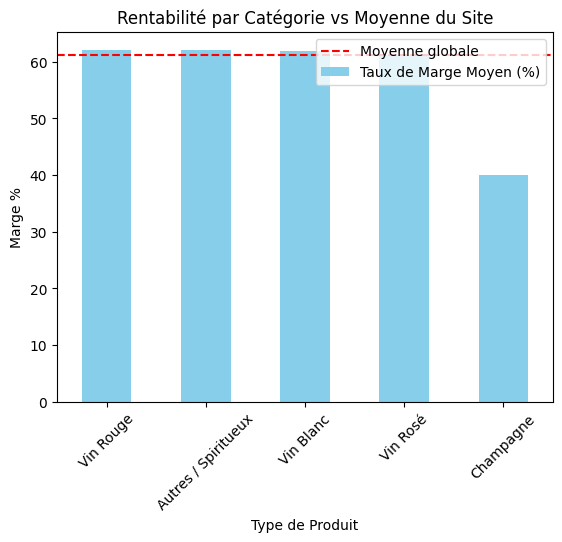

Taux de marge moyen : 61.22%


In [ ]:
# Graphique de la marge par catégorie
plt.figure(figsize=(10, 6))
df_marge_par_type.plot(kind='bar', x='Type de Produit', y='Taux de Marge Moyen (%)', 
                       color='skyblue', legend=False)
plt.axhline(y=df_cleaned['taux_de_marge'].mean(), color='red', linestyle='--', label='Moyenne globale')
plt.title('Rentabilité par Catégorie vs Moyenne du Site')
plt.ylabel('Marge %')
plt.xticks(rotation=45)
plt.legend()
plt.show()      
print("Taux de marge moyen : {:.2f}%".format(df_cleaned['taux_de_marge'].mean()))

Bloc 3 : Corrélation & Stratégie (3 min)
On explique le lien entre le prix et les ventes (ton fameux -0.52).

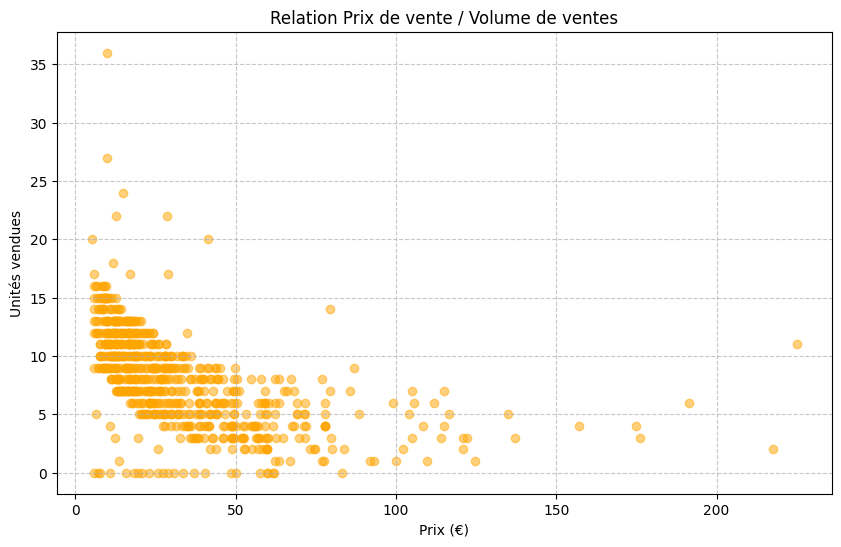

Coefficient de corrélation Prix/Ventes : -0.52


In [ ]:
# Un nuage de points pour illustrer la corrélation négative
plt.figure(figsize=(10, 6))
plt.scatter(df_cleaned['price'], df_cleaned['total_sales'], alpha=0.5, c='orange')
plt.title('Relation Prix de vente / Volume de ventes')
plt.xlabel('Prix (€)')
plt.ylabel('Unités vendues')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Coefficient de corrélation Prix/Ventes : {df_cleaned['price'].corr(df_cleaned['total_sales']):.2f}")

Bloc 4 : Conclusions & Recommandations (2 min)
Tu termines sur une note business. Tu peux afficher ce texte directement dans une cellule Markdown ou via un print.

In [ ]:
print("""
🚀 RECOMMANDATIONS STRATÉGIQUES :
--------------------------------------------------
1. CORRECTION : Mettre à jour les prix d'achat/vente du segment 'Alertes'.
2. MARKETING : Booster les catégories à forte marge (> 40%).
3. STOCK : Réduire le stock sur les bouteilles à plus de 100€ (rotation faible).
4. LIVRABLE : Le fichier 'Reporting_Final.xlsx' est prêt pour les équipes.
""")


🚀 RECOMMANDATIONS STRATÉGIQUES :
--------------------------------------------------
1. CORRECTION : Mettre à jour les prix d'achat/vente du segment 'Alertes'.
2. MARKETING : Booster les catégories à forte marge (> 40%).
3. STOCK : Réduire le stock sur les bouteilles à plus de 100€ (rotation faible).
4. LIVRABLE : Le fichier 'Reporting_Final.xlsx' est prêt pour les équipes.

